Import dependencies/libraries and the dataset

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

Define the features (X) and the target (y)

In [48]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split the dataset into 70% training and 30% test

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Test the performance of KNN and determine the best value of K to choose. Use Euclidean distance

k = 1 => Training Accuracy: 1.0000, Test Accuracy: 0.7575
k = 5 => Training Accuracy: 0.8534, Test Accuracy: 0.7886
k = 6 => Training Accuracy: 0.8403, Test Accuracy: 0.7946
k = 7 => Training Accuracy: 0.8401, Test Accuracy: 0.7939
k = 8 => Training Accuracy: 0.8313, Test Accuracy: 0.7974
k = 10 => Training Accuracy: 0.8257, Test Accuracy: 0.7985
k = 15 => Training Accuracy: 0.8192, Test Accuracy: 0.7951
k = 20 => Training Accuracy: 0.8122, Test Accuracy: 0.7965
k = 25 => Training Accuracy: 0.8100, Test Accuracy: 0.7975
k = 30 => Training Accuracy: 0.8063, Test Accuracy: 0.7983


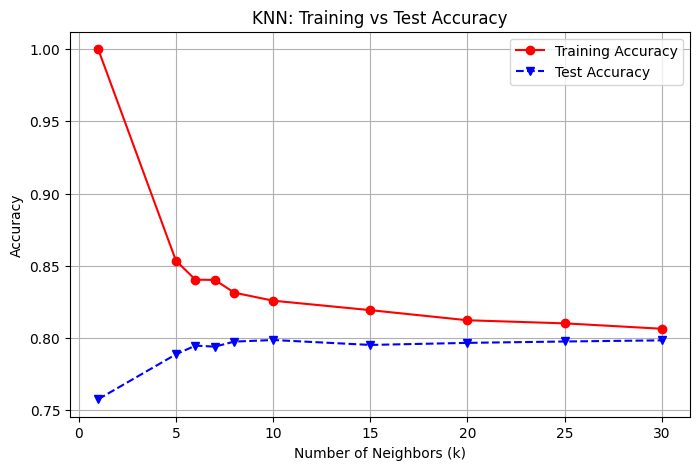

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    y_predTrain = clf1.predict(X_train)
    y_predTest = clf1.predict(X_test)
    trainAcc.append(accuracy_score(y_train, y_predTrain))
    testAcc.append(accuracy_score(y_test, y_predTest))
    print(f"k = {k} => Training Accuracy: {accuracy_score(y_train, y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, y_predTest):.4f}")

plt.figure(figsize=(8,5))
plt.plot(numNeighbors, trainAcc, 'ro-', label='Training Accuracy')
plt.plot(numNeighbors, testAcc, 'bv--', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Cross-validation with 5-fold to determine best value for K

k = 1 => CV Accuracy (on training set): 0.7525 (+/- 0.0092)
k = 5 => CV Accuracy (on training set): 0.7845 (+/- 0.0066)
k = 6 => CV Accuracy (on training set): 0.7924 (+/- 0.0094)
k = 7 => CV Accuracy (on training set): 0.7906 (+/- 0.0076)
k = 8 => CV Accuracy (on training set): 0.7945 (+/- 0.0070)
k = 10 => CV Accuracy (on training set): 0.7952 (+/- 0.0082)
k = 15 => CV Accuracy (on training set): 0.7929 (+/- 0.0066)
k = 20 => CV Accuracy (on training set): 0.7943 (+/- 0.0073)
k = 25 => CV Accuracy (on training set): 0.7932 (+/- 0.0071)
k = 30 => CV Accuracy (on training set): 0.7938 (+/- 0.0080)

Best k (based on training set CV): 10 with a 5-Fold CV Accuracy of: 0.7952


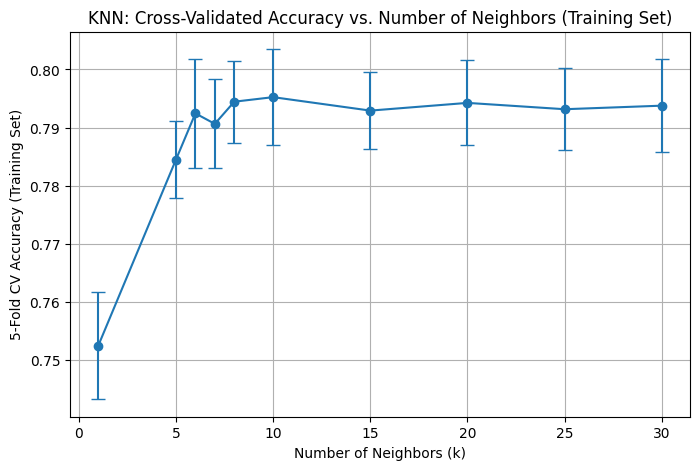

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define the k values to test
num_neighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mean_scores = []
cv_std_scores = []

# Loop through each k value and perform 5-fold cross-validation on the training set
for k in num_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())
    print(f"k = {k} => CV Accuracy (on training set): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Identify the best k value based on cross-validation on the training set
best_index = np.argmax(cv_mean_scores)
best_k = num_neighbors[best_index]
best_accuracy = cv_mean_scores[best_index]
print(f"\nBest k (based on training set CV): {best_k} with a 5-Fold CV Accuracy of: {best_accuracy:.4f}")

# Plot the cross-validation results with error bars showing the standard deviation
plt.figure(figsize=(8,5))
plt.errorbar(num_neighbors, cv_mean_scores, yerr=cv_std_scores, fmt='o-', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('5-Fold CV Accuracy (Training Set)')
plt.title('KNN: Cross-Validated Accuracy vs. Number of Neighbors (Training Set)')
plt.grid(True)
plt.show()


Mean and Standard Deviation, Paired t-Test for K value to choose between 10 or 20

k=10 scores: [0.79115646 0.78095238 0.80119048 0.79965986 0.80323129]
k=20 scores: [0.79251701 0.78078231 0.79846939 0.79846939 0.80102041]
Mean Accuracy for k=10: 0.7952 (std: 0.0082)
Mean Accuracy for k=20: 0.7943 (std: 0.0073)
Mean difference (k=20 - k=10): -0.0010
Paired t-test: t-statistic = 1.3470, p-value = 0.2492


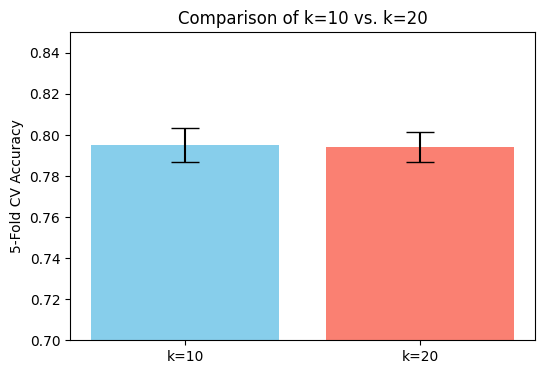

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# Compute cross-validation scores for k=10 and k=20 on the training set
knn10 = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
scores_k10 = cross_val_score(knn10, X_train, y_train, cv=5, scoring='accuracy')

knn20 = KNeighborsClassifier(n_neighbors=20, metric='minkowski', p=2)
scores_k20 = cross_val_score(knn20, X_train, y_train, cv=5, scoring='accuracy')

# Print the individual fold scores
print("k=10 scores:", scores_k10)
print("k=20 scores:", scores_k20)

# Calculate the means and standard deviations
mean_k10 = np.mean(scores_k10)
mean_k20 = np.mean(scores_k20)
std_k10 = np.std(scores_k10)
std_k20 = np.std(scores_k20)

print(f"Mean Accuracy for k=10: {mean_k10:.4f} (std: {std_k10:.4f})")
print(f"Mean Accuracy for k=20: {mean_k20:.4f} (std: {std_k20:.4f})")
print(f"Mean difference (k=20 - k=10): {mean_k20 - mean_k10:.4f}")

# Perform a paired t-test
t_stat, p_value = ttest_rel(scores_k10, scores_k20)
print(f"Paired t-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

# Visualize the comparison using a bar chart with error bars
labels = ['k=10', 'k=20']
means = [mean_k10, mean_k20]
stds = [std_k10, std_k20]

plt.figure(figsize=(6,4))
plt.bar(labels, means, yerr=stds, capsize=10, color=['skyblue', 'salmon'])
plt.ylabel('5-Fold CV Accuracy')
plt.title('Comparison of k=10 vs. k=20')
plt.ylim(0.7, 0.85)
plt.show()


Confusion Matrix for K=10 KNN Model training

Final Test Accuracy: 0.7984920634920635
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82      6278
           1       0.87      0.70      0.78      6322

    accuracy                           0.80     12600
   macro avg       0.81      0.80      0.80     12600
weighted avg       0.81      0.80      0.80     12600

Confusion Matrix:
[[5628  650]
 [1889 4433]]


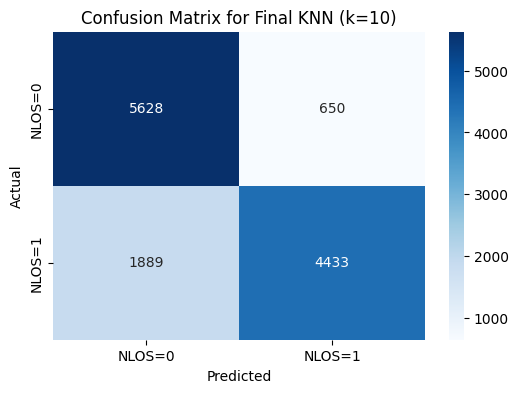

In [ ]:
# Final Model Training and Evaluation using k=10

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create and train the final KNN model on the training set
final_knn = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
final_knn.fit(X_train, y_train)

# Predict on the test set
y_pred = final_knn.predict(X_test)

# Evaluate performance: Accuracy, Classification Report, and Confusion Matrix
final_accuracy = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", final_accuracy)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Final KNN (k=10)")
plt.show()
